# MALI on toy atoms

`spectra.Experimental.MALI` is the prototype of the MALI loop
(Multilevel Accelerated Lambda Iteration, Rybicki & Hummer 1991, 1992):

```
until converged:
    n(k)  ->  opacity chi(lambda,k), line source S      (populations tier)
    for each (lambda, mu):                              (jitted sweep)
        Feautrier formal solve  ->  j, Psi
        accumulate  Jbar  and  Lambda_star  per line    (profile-weighted, /wphi)
    precondition the rate matrix with Lambda_star
    solve SE depth by depth  ->  new n(k)
```

Everything is verified on **fabricated toy atoms** against analytic or
structural oracles -- real atomic data would add failure modes without adding
verification power.

This notebook is **generated** from `build_notebook.py` in this folder.

## The three compute tiers

| tier | runs | contents |
|---|---|---|
| once | per model | global mesh, windows, quadrature weights |
| per depth, per $(T_e, N_e)$ | before the loop | LTE ratios, collision rates, profile tables, `wphi`, passive b-f rates |
| per iteration | hot path (jitted) | opacity, formal sweep, $\bar J$, $\Lambda^{*}$, preconditioned SE |

The middle tier exists because LTE ratios, collision rates and the absorption
profile depend only on local thermodynamics -- never on populations -- so the
iteration never recomputes them.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from spectra import Constants as CST
from spectra.Experimental.MALI import GlobalMesh, Loop, Structs
from spectra.Util import MeshUtil

XI_REF = 2.5e5  # scalar ruler: 2.5 km/s in cm/s


def build(atom, ND=41, Nt=1e10, Ne=1e10, Te_top=6e3, Te_bottom=None, nLambda=41):
    """Toy 1D slab (log-spaced depth -> log-spaced tau) + mesh + precompute."""
    Zmax = 1.0e9
    Z = np.concatenate([[0.0], np.logspace(np.log10(Zmax * 1e-8), np.log10(Zmax), ND - 1)])
    atmos = Structs.make_toy_atmos_(ND, Zmax, Te_top=Te_top, Te_bottom=Te_bottom, Ne=Ne, Nt=Nt)
    atmos.Z = Z
    q = MeshUtil.make_full_line_mesh_(nLambda, 2.5, 10.0)
    meshes = [GlobalMesh.anchor_line_mesh_(q, w0, XI_REF) for w0 in atom.Line["w0"]]
    mesh = GlobalMesh.merge_meshes_(meshes)
    pre = Structs.precompute_(atom, atmos, mesh)
    return atmos, mesh, pre


## 1. The global wavelength axis

Each line's dimensionless template $q$ is anchored with **one scalar ruler**,
$\lambda = \lambda_0\,(1 + q\,\xi_{\rm ref}/c)$ -- not with the local Doppler
width. That single choice is what makes the axis shareable across depths: no
local quantity ever touches it. All per-line arrays are then merged, sorted and
deduplicated into one axis; each line keeps only an offset (`Nblue`) and a span
into it.


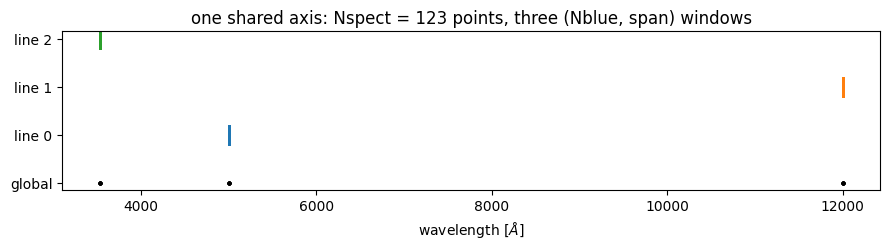

windows (Nblue, span): [(41, 41), (82, 41), (0, 41)]


In [2]:
atom3 = Structs.make_toy_atom_3lv_()
atmos3, mesh3, pre3 = build(atom3)

fig, ax = plt.subplots(figsize=(9, 2.6))
for kL in range(atom3.nLine):
    win = mesh3.wl[mesh3.Nblue[kL] : mesh3.Nblue[kL] + mesh3.span[kL]]
    ax.plot(win * 1e8, np.full(win.size, kL), "|", ms=14)
ax.plot(mesh3.wl * 1e8, np.full(mesh3.wl.size, -1), ".", ms=3, color="k")
ax.set_yticks([-1, 0, 1, 2], ["global", "line 0", "line 1", "line 2"])
ax.set_xlabel(r"wavelength [$\AA$]")
ax.set_title(f"one shared axis: Nspect = {mesh3.wl.size} points, three (Nblue, span) windows")
plt.tight_layout()
plt.show()

print("windows (Nblue, span):", list(zip(mesh3.Nblue.tolist(), mesh3.span.tolist(), strict=True)))


## 2. The profile table: one axis, depth-dependent *values*

Depth dependence enters only through the coordinate transform
$x = (\lambda - \lambda_0)/\Delta\lambda_D(k)$ -- a **division** by the local
width where the 0-D code *multiplies* the template by it. Every row of the
table is evaluated at the same columns; a hot deep layer just fills its row
with a broader shape.

`wphi` records the numerical norm $\sum_j w_j\,\varphi_{jk}$ (analytically 1)
of each row on its window. Rate integrals divide by it, so the profile-area
part of any quadrature error cancels identically.


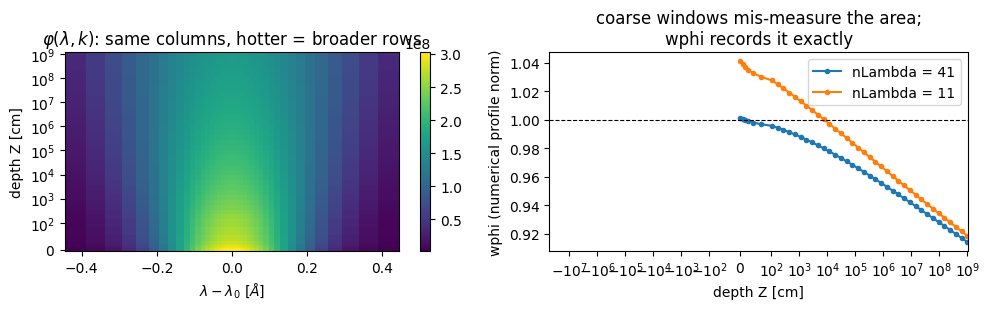

In [3]:
# a temperature ramp so rows differ visibly
atmosR, meshR, preR = build(atom3, Te_top=6e3, Te_bottom=2.4e4)
i0, i1 = preR.win_off[0]
win_AA = (meshR.wl[meshR.Nblue[0] : meshR.Nblue[0] + meshR.span[0]] - atom3.Line["w0"][0]) * 1e8

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
im = axes[0].pcolormesh(win_AA, atmosR.Z, preR.phi[i0:i1, :].T, shading="nearest")
axes[0].set_yscale("symlog", linthresh=1e2)
axes[0].set_xlabel(r"$\lambda - \lambda_0$ [$\AA$]")
axes[0].set_ylabel("depth Z [cm]")
axes[0].set_title(r"$\varphi(\lambda, k)$: same columns, hotter = broader rows")
fig.colorbar(im, ax=axes[0])

for nL in (41, 11):
    _, _, preN = build(atom3, Te_top=6e3, Te_bottom=2.4e4, nLambda=nL)
    axes[1].plot(atmosR.Z, preN.wphi[:, 0], "o-", ms=3, label=f"nLambda = {nL}")
axes[1].axhline(1.0, color="k", lw=0.8, ls="--")
axes[1].set_xscale("symlog", linthresh=1e2)
axes[1].set_xlabel("depth Z [cm]")
axes[1].set_ylabel("wphi (numerical profile norm)")
axes[1].set_title("coarse windows mis-measure the area;\nwphi records it exactly")
axes[1].legend()
plt.tight_layout()
plt.show()


## 3. Two-level atom: the loop machinery against exact oracles

No closed-form $S(\tau)$ exists for the CRD line-profile problem, but exact
statements do, and each pins a different part of the machinery:

- $\varepsilon = 1$: $S = B$ after **exactly one** iteration;
- the $\sqrt{\varepsilon}$ surface law $S(0) = \sqrt{\varepsilon}\,B$
  (profile-shape independent, thick slab, constant $\varepsilon, B$) --
  exercises mesh, profile table, `wphi`, angle quadrature and RT together;
- plain $\Lambda$-iteration ($\Lambda^{*} = 0$) must reach the **same** fixed
  point, an order of magnitude more slowly;
- a deliberately halved $\Lambda^{*}$ must also reach it: the operator cancels
  at $S_{\rm new} = S_{\rm old}$, so it can change the *rate*, never the
  *answer*.


In [4]:
atom2 = Structs.make_toy_atom_2lv_()


def two_level(eps_v, tau_target, use_lstar=True, lstar_scale=1.0, tol=1e-9, ND=61):
    atmos, _mesh, pre = build(atom2, ND=ND)
    phi_win = pre.phi[pre.win_off[0, 0] : pre.win_off[0, 1], :]
    w_win = pre.weight[pre.win_off[0, 0] : pre.win_off[0, 1]]
    wphi = pre.wphi[:, 0]
    B = pre.planck_w0[:, 0]
    phi_c = phi_win[phi_win.shape[0] // 2, 0]
    chi0 = np.full(ND, tau_target / (phi_c * atmos.Z[-1]))
    eps = np.full(ND, eps_v)
    r = Loop.mali_two_level_(
        atmos.Z, chi0, eps, B, phi_win, w_win, wphi,
        tol=tol, itmax=20000, use_lstar=use_lstar, lstar_scale=lstar_scale,
    )
    return r, B


eps_grid = [1e-1, 1e-2, 1e-3, 1e-4]
surface = []
for eps_v in eps_grid:
    r, B = two_level(eps_v, tau_target=100.0 / eps_v)
    surface.append(r.S[0] / B[0])
    print(f"eps = {eps_v:7.0e}: S(0)/B = {r.S[0] / B[0]:.5f}  (sqrt(eps) = {np.sqrt(eps_v):.5f}),  {r.niter} iterations")


eps =   1e-01: S(0)/B = 0.31727  (sqrt(eps) = 0.31623),  44 iterations
eps =   1e-02: S(0)/B = 0.10058  (sqrt(eps) = 0.10000),  107 iterations
eps =   1e-03: S(0)/B = 0.03186  (sqrt(eps) = 0.03162),  183 iterations
eps =   1e-04: S(0)/B = 0.01009  (sqrt(eps) = 0.01000),  271 iterations


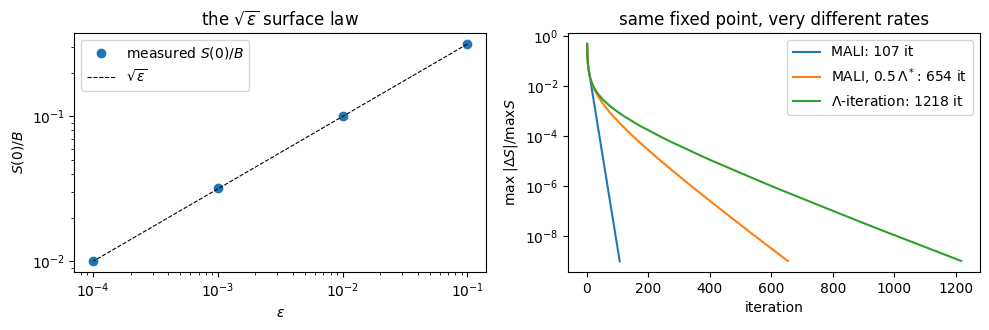

max |S_half - S_mali| / B = 4.53e-08
max |S_lam  - S_mali| / B = 9.05e-08


In [5]:
r_mali, B = two_level(1e-2, 1e4)
r_half, _ = two_level(1e-2, 1e4, lstar_scale=0.5)
r_lam, _ = two_level(1e-2, 1e4, use_lstar=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].loglog(eps_grid, surface, "o", label="measured $S(0)/B$")
axes[0].loglog(eps_grid, np.sqrt(eps_grid), "k--", lw=0.8, label=r"$\sqrt{\varepsilon}$")
axes[0].set_xlabel(r"$\varepsilon$")
axes[0].set_ylabel("$S(0)/B$")
axes[0].set_title(r"the $\sqrt{\varepsilon}$ surface law")
axes[0].legend()

labels = ("MALI", r"MALI, $0.5\,\Lambda^*$", r"$\Lambda$-iteration")
for r, lab in zip((r_mali, r_half, r_lam), labels, strict=True):
    axes[1].semilogy(np.arange(1, r.niter + 1), r.dS_history, label=f"{lab}: {r.niter} it")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel(r"max $|\Delta S| / \max S$")
axes[1].set_title("same fixed point, very different rates")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"max |S_half - S_mali| / B = {np.abs(r_half.S - r_mali.S).max() / B[0]:.2e}")
print(f"max |S_lam  - S_mali| / B = {np.abs(r_lam.S - r_mali.S).max() / B[0]:.2e}")


## 4. Three-level atom: the preconditioned rate matrix

The multilevel update assembles per-transition **effective rates**
($A_{ji}(1-\Lambda^{*})$, and $\bar J_{\rm eff} = \bar J - \Lambda^{*} S$ in
both rate directions) and feeds the *unchanged* production rate-matrix
builders (`SEsolver.set_matrixR_/set_matrixC_/solve_SE_`), one independent
$N_L \times N_L$ solve per depth. Locality of that solve -- a consequence of
$\Lambda^{*}$ being diagonal -- is the entire cost advantage of MALI over
complete linearization.

Departure coefficients $b_i = n_i / n_i^{\rm LTE}$ show the classic NLTE
signature: thermalized at depth, scattering-depleted near the surface -- and
collision domination drives every $b_i \to 1$.


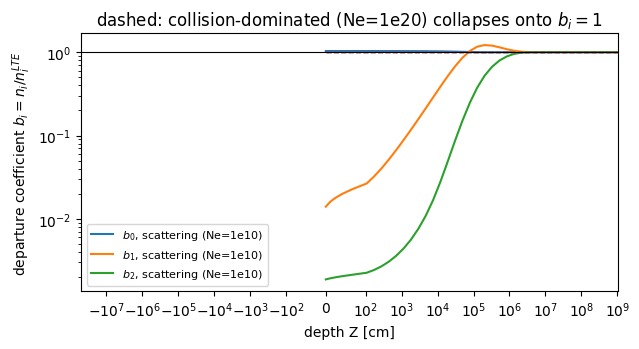

NLTE run: 166 iterations;  collision-dominated: 2 iterations
collision-dominated max |n/n_LTE - 1| = 1.09e-06


In [6]:
r_nlte = Loop.mali_multilevel_(atom3, atmos3, mesh3, pre3, tol=1e-10)
atmosC, meshC, preC = build(atom3, Ne=1e20)  # C*Ne = 1e12 >> A ~ 1e8
r_lte = Loop.mali_multilevel_(atom3, atmosC, meshC, preC, tol=1e-10)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for i in range(3):
    ax.plot(atmos3.Z, r_nlte.n[:, i] / pre3.n_LTE[:, i], label=f"$b_{i}$, scattering (Ne=1e10)")
for i in range(3):
    ax.plot(atmosC.Z, r_lte.n[:, i] / preC.n_LTE[:, i], "--", lw=1)
ax.axhline(1.0, color="k", lw=0.8)
ax.set_xscale("symlog", linthresh=1e2)
ax.set_yscale("log")
ax.set_xlabel("depth Z [cm]")
ax.set_ylabel("departure coefficient $b_i = n_i/n_i^{LTE}$")
ax.set_title("dashed: collision-dominated (Ne=1e20) collapses onto $b_i = 1$")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"NLTE run: {r_nlte.niter} iterations;  collision-dominated: {r_lte.niter} iterations")
print(f"collision-dominated max |n/n_LTE - 1| = {np.abs(r_lte.n / preC.n_LTE - 1).max():.2e}")


### The single-channel oracle

A level reachable through exactly **one** transition carries zero net flux in
steady state, so it cannot back-react: the 0-1 excitation balance of a 3-level
atom whose level 2 hangs off level 1 alone must be *identical* to the pure
two-level atom (level 2 is placed high so its tiny population cannot shift the
opacity). This is the multilevel machinery reducing to the verified two-level
case -- with full-strength, well-conditioned rates.


In [7]:
E1 = CST.h_ * CST.c_ / 5000e-8
E2 = E1 + CST.h_ * CST.c_ / 1500e-8
atom_sc = Structs.make_toy_atom_(
    np.array([1.0, 3.0, 5.0]), np.array([0.0, E1, E2]),
    [(0, 1), (1, 2)], np.array([1e8, 3e7]), np.array([1e-8, 1e-8]),
)
r_sc = Loop.mali_multilevel_(atom_sc, *build(atom_sc), tol=1e-12)
atmos2b, mesh2b, pre2b = build(atom2)
r_2lv = Loop.mali_multilevel_(atom2, atmos2b, mesh2b, pre2b, tol=1e-12)

ratio_sc = r_sc.n[:, 1] / r_sc.n[:, 0]
ratio_2lv = r_2lv.n[:, 1] / r_2lv.n[:, 0]
print(f"max |ratio_3lv / ratio_2lv - 1| = {np.abs(ratio_sc / ratio_2lv - 1).max():.2e}")
print(f"max n_2 = {r_sc.n[:, 2].max():.2e}  (high level: spectator, not actor)")


max |ratio_3lv / ratio_2lv - 1| = 9.73e-10
max n_2 = 4.60e-09  (high level: spectator, not actor)


## 5. Passive continuum: the active/passive seam

`make_toy_atom_2lv_cont_()` adds an ion ground level and two b-f transitions.
They are **passive**: their rates come from a *prescribed* radiation field via
the production `SELib._bf_R_rate_` (fabricated hydrogenic cross sections,
$\alpha \propto (\lambda/\lambda_0)^3$) and enter the rate matrix
**unpreconditioned** -- there is no self-feedback to remove when the radiation
is not solved for. This is exactly full MALI's rate-matrix structure: active
(preconditioned) lines and passive (prescribed) transitions side by side in
the same $\Gamma$.

With PI intensity = Planck($T_e$) the b-f rates detail-balance, so collision
domination must land the populations on **Saha-Boltzmann** LTE -- ionization
fraction included.


In [8]:
atomK = Structs.make_toy_atom_2lv_cont_()
atmosK, meshK, preK = build(atomK, Ne=1e20)
rK = Loop.mali_multilevel_(atomK, atmosK, meshK, preK, tol=1e-10)
print(f"levels: 2 bound + 1 continuum;  transitions: {atomK.nLine} active line + {atomK.nCont} passive b-f")
print(f"max |n/n_LTE - 1| = {np.abs(rK.n / preK.n_LTE - 1).max():.2e}   ({rK.niter} iterations)")
print(f"ion fraction: SE = {rK.n[0, 2]:.4e},  Saha = {preK.n_LTE[0, 2]:.4e}")


levels: 2 bound + 1 continuum;  transitions: 1 active line + 2 passive b-f
max |n/n_LTE - 1| = 1.19e-06   (2 iterations)
ion fraction: SE = 1.6186e-02,  Saha = 1.6186e-02


## Summary

- one **global wavelength axis** (scalar-ruler anchor, merge, offset+span
  windows) shared by every depth -- the precondition for multi-D RT;
- profile tables put all depth dependence into **values**, never the axis;
  `wphi` renormalization cancels the profile-area quadrature error exactly;
- the jitted sweep returns $\bar J$ and the diagonal operator per line in the
  same pass (`formal_improved_RH_(..., with_psi=True)`);
- the Rybicki & Hummer preconditioning is form-preserving: effective rates in,
  unchanged production SE kernels out, one local solve per depth;
- verified: $\sqrt{\varepsilon}$ law, fixed-point independence of
  $\Lambda^{*}$, single-channel reduction to two-level, Boltzmann and
  Saha-Boltzmann limits.

**Deliberate toy-scale limitations** (full-MALI work): static atmosphere (no
Doppler shifts -- needs the dual-mesh SE quadrature), disjoint line windows
(overlap needs per-column opacity accumulation), no background continuum
opacity in the RT, continua passive-only, fixed $N_e$, thermal lower boundary.
